# ♠️ EDA и кластеризация игроков

**Этап 3** проекта *Texas Hold'em ETL & Analytics Pipeline*.

В предыдущих этапах мы загрузили 1000 раздач в SQLite и построили SQL-витрину
`v_player_stats`, где стиль игрока (`player_style`) определяется **правилом**,
написанным вручную (пороги по VPIP и PFR). Здесь проверяем гипотезу:

> Может ли алгоритм **без учителя** (K-Means) сам найти те же 4 профиля —
> Nit, TAG, LAG и Loose-Passive (Fish) — только по префлоп-статистике?

У синтетических данных есть редкое преимущество — **ground truth**: генератор
сохранил настоящий архетип каждого игрока в `data/raw/player_profiles.csv`.
Поэтому качество кластеризации можно измерить честно, а не «на глаз».

**Содержание**
1. Загрузка данных из витрины
2. Разведочный анализ (EDA): корреляции метрик, распределение банков
3. K-Means: выбор числа кластеров и обучение
4. Сравнение кластеров с SQL-правилом и ground truth
5. PCA: проекция кластеров на плоскость
6. Динамика банкролла (оконные функции SQL)
7. Выводы

## 0. Настройка окружения

Переиспользуем код из `src/analytics.py`: единый стиль графиков, палитру и
функцию установки SQL-витрин. Так ноутбук и скрипты выглядят как одна система.

In [1]:
from __future__ import annotations

import sqlite3
import sys
from contextlib import closing
from pathlib import Path
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import pandas as pd
from matplotlib.axes import Axes
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.figure import Figure
from matplotlib.lines import Line2D
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import StandardScaler

# Ноутбук запускается из notebooks/ — корень репозитория на уровень выше
PROJECT_ROOT: Final[Path] = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from analytics import (  # noqa: E402  — импорт после настройки sys.path
    ARCHETYPE_TO_STYLE,
    BASELINE_COLOR,
    GRID_COLOR,
    INK_MUTED,
    INK_PRIMARY,
    INK_SECONDARY,
    LOSS_COLOR,
    NEUTRAL_MID,
    STYLE_MARKERS,
    STYLE_ORDER,
    WIN_COLOR,
    apply_chart_style,
    install_views,
)

DB_PATH: Final[Path] = PROJECT_ROOT / "data" / "poker_analytics.db"
SQL_PATH: Final[Path] = PROJECT_ROOT / "sql" / "analytics_queries.sql"
PROFILES_PATH: Final[Path] = PROJECT_ROOT / "data" / "raw" / "player_profiles.csv"
FIGURES_DIR: Final[Path] = PROJECT_ROOT / "reports" / "figures"

FEATURES: Final[list[str]] = ["vpip_pct", "pfr_pct", "three_bet_pct"]
N_CLUSTERS: Final[int] = 4
K_RANGE: Final[range] = range(2, 9)
RANDOM_STATE: Final[int] = 42
TOP_N_BANKROLL: Final[int] = 3

# Категориальная палитра (проверена на различимость при дальтонизме).
# Цвет закреплён за СТИЛЕМ, а не за номером кластера — чтобы легенды совпадали.
STYLE_COLORS: Final[dict[str, str]] = {
    "Nit": "#2a78d6", "TAG": "#eb6834", "LAG": "#1baf7a", "Loose-Passive": "#eda100",
}

apply_chart_style()
pd.set_option("display.precision", 2)
pd.set_option("display.width", 140)


def query(sql: str, params: dict[str, object] | None = None) -> pd.DataFrame:
    """Выполняет SQL к poker_analytics.db и возвращает DataFrame."""
    with closing(sqlite3.connect(DB_PATH)) as conn:
        return pd.read_sql_query(sql, conn, params=params)


def save_figure(fig: Figure, name: str) -> None:
    """Сохраняет график в reports/figures (для README), не закрывая его в ноутбуке."""
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES_DIR / name, dpi=200)

## 1. Загрузка данных из витрины

Пересоздаём витрины (скрипт идемпотентен) и забираем профиль каждого игрока.
К витрине присоединяем скрытый архетип из генератора — он понадобится только
для оценки качества, **в обучении не участвует**.

In [2]:
with closing(sqlite3.connect(DB_PATH)) as connection:
    install_views(connection, SQL_PATH)

players = query("SELECT * FROM v_player_stats ORDER BY player_id")
profiles = pd.read_csv(PROFILES_PATH, usecols=["name", "archetype"])
players = players.merge(profiles, left_on="player_name", right_on="name", how="left").drop(columns="name")
players["true_style"] = players["archetype"].map(ARCHETYPE_TO_STYLE)

print(f"Игроков: {len(players)}, раздач на игрока: {players['hands'].min()}–{players['hands'].max()}")
display(players[["player_name", "hands", *FEATURES, "aggression_factor", "wtsd_pct",
                 "bb_per_100", "player_style", "archetype"]].head(8))

Игроков: 30, раздач на игрока: 171–223


,player_name,hands,vpip_pct,pfr_pct,three_bet_pct,aggression_factor,wtsd_pct,bb_per_100,player_style,archetype
0,BigAce,212,33.0,24.5,5.6,4.00,39.0,38.92,LAG,LAG
1,BigRiver,197,26.4,20.3,11.3,4.80,38.7,93.65,LAG,LAG
2,BigShark,203,35.5,14.3,0.0,0.53,72.3,-150.25,Loose-Passive,Fish
3,ColdAce,214,21.5,17.3,9.5,5.67,46.9,73.49,TAG,TAG
4,ColdDonk,205,31.2,9.3,0.0,0.44,57.1,-84.46,Loose-Passive,Fish
5,ColdManiac,192,29.7,23.4,14.3,7.33,21.2,-50.26,LAG,LAG
6,DarkDonk,216,13.0,9.3,0.0,0.88,19.0,21.53,Nit,Nit
7,DarkFish,196,29.1,12.8,6.0,0.78,56.5,-50.26,Loose-Passive,Fish


## 2. Разведочный анализ (EDA)

### 2.1. Описательные статистики и пропуски
`three_bet_pct` = NULL означает, что у игрока не было ни одной возможности 3-бета.
Такое возможно на малой выборке; для кластеризации заменим NULL на 0 —
«не 3-бетил» — и явно это зафиксируем.

In [3]:
metric_columns = [*FEATURES, "aggression_factor", "wtsd_pct", "bb_per_100"]
print("Пропуски по метрикам:")
print(players[metric_columns].isna().sum().to_string())
display(players[metric_columns].describe().T[["mean", "std", "min", "50%", "max"]])

Пропуски по метрикам:
vpip_pct             0
pfr_pct              0
three_bet_pct        0
aggression_factor    1
wtsd_pct             0
bb_per_100           0


,mean,std,min,50%,max
vpip_pct,21.25,8.69,5.40,20.55,38.90
pfr_pct,14.00,5.53,2.50,13.20,24.90
three_bet_pct,4.84,4.02,0.00,4.15,14.30
aggression_factor,3.54,2.55,0.44,3.00,10.00
wtsd_pct,46.59,15.37,19.00,46.80,77.40
bb_per_100,-0.35,64.33,-150.25,-0.63,115.27


### 2.2. Корреляции метрик
Если признаки сильно коррелированы, K-Means фактически «видит» меньше измерений,
а PCA сможет сжать их почти без потерь.

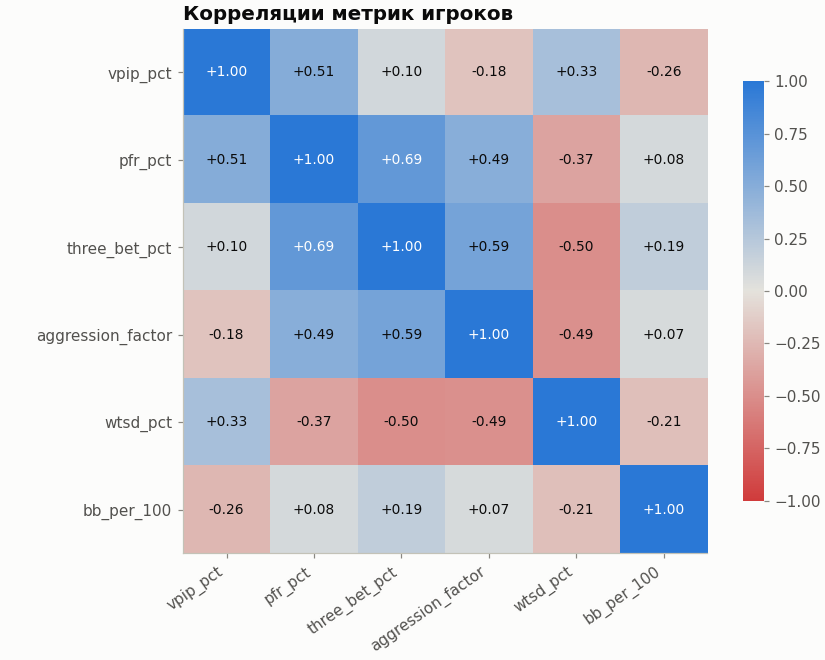

In [4]:
def plot_correlation_matrix(frame: pd.DataFrame, columns: list[str]) -> Figure:
    """Тепловая карта корреляций Пирсона с подписанными значениями."""
    corr = frame[columns].corr().to_numpy()
    cmap = LinearSegmentedColormap.from_list("corr", [LOSS_COLOR, NEUTRAL_MID, WIN_COLOR])

    fig, ax = plt.subplots(figsize=(7.5, 6), layout="constrained")
    image = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
    ax.grid(False)
    ax.set_xticks(range(len(columns)), columns, rotation=35, ha="right")
    ax.set_yticks(range(len(columns)), columns)
    # Подписи значений: тёмный текст на светлых ячейках, белый — на насыщенных
    for (row, col), value in np.ndenumerate(corr):
        ax.text(col, row, f"{value:+.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(value) > 0.6 else INK_PRIMARY)
    colorbar = fig.colorbar(image, ax=ax, shrink=0.8)
    colorbar.outline.set_visible(False)
    ax.set_title("Корреляции метрик игроков")
    return fig


fig_corr = plot_correlation_matrix(players.fillna({"three_bet_pct": 0}), metric_columns)
save_figure(fig_corr, "eda_correlation.png")
plt.show()

### 2.3. Распределение размера банка
Банк в больших блайндах сильно скошен вправо: большинство раздач заканчиваются
префлопом за 1.5–4 BB, а редкие олл-ины нескольких игроков доходят до 300 BB.
Поэтому — логарифмическая ось X.

,count,mean,50%,max
outcome,,,,
Дошла до флопа,390.0,29.34,12.0,301.00
Закончилась префлоп,610.0,3.96,4.0,48.19


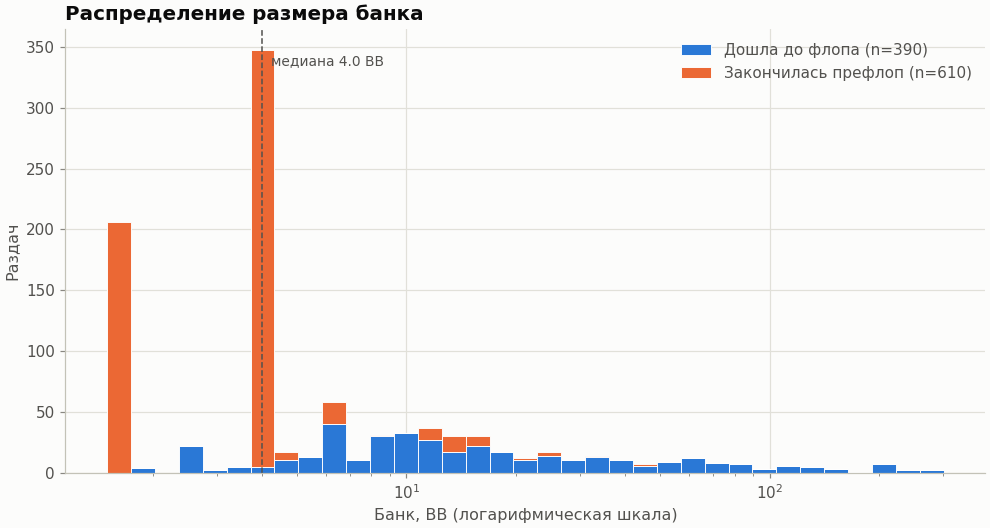

In [5]:
pots = query(
    """
    SELECT CAST(h.pot_size AS REAL) / h.big_blind AS pot_bb,
           CASE WHEN s.street_name = 'preflop' THEN 'Закончилась префлоп'
                ELSE 'Дошла до флопа' END   AS outcome
    FROM hands   AS h
    JOIN streets AS s ON s.street_id = h.final_street_id
    """
)


def plot_pot_distribution(pots_frame: pd.DataFrame) -> Figure:
    """Гистограмма банков в BB на лог-шкале, раздельно по исходу раздачи."""
    bins = np.geomspace(pots_frame["pot_bb"].min(), pots_frame["pot_bb"].max(), 36)
    fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
    groups = list(pots_frame.groupby("outcome", sort=False))
    # stacked=True: столбцы складываются, а не перекрывают друг друга
    ax.hist([group["pot_bb"] for _, group in groups], bins=bins, stacked=True,
            color=[WIN_COLOR, "#eb6834"][: len(groups)], edgecolor="white", linewidth=0.6,
            label=[f"{label} (n={len(group)})" for label, group in groups])
    median = pots_frame["pot_bb"].median()
    ax.axvline(median, color=INK_SECONDARY, linestyle="--", linewidth=1)
    ax.annotate(f"медиана {median:.1f} BB", xy=(median, ax.get_ylim()[1] * 0.92),
                xytext=(6, 0), textcoords="offset points", color=INK_SECONDARY, fontsize=9)
    ax.set_xscale("log")
    ax.set(xlabel="Банк, BB (логарифмическая шкала)", ylabel="Раздач")
    ax.legend(loc="upper right")
    ax.set_title("Распределение размера банка")
    return fig


display(pots.groupby("outcome")["pot_bb"].describe()[["count", "mean", "50%", "max"]])
fig_pots = plot_pot_distribution(pots)
save_figure(fig_pots, "eda_pot_distribution.png")
plt.show()

## 3. K-Means

### 3.1. Подготовка признаков
Признаки — три префлоп-частоты: **VPIP** (насколько лузовый), **PFR** (насколько
агрессивный), **3-bet %** (насколько агрессивен против рейзов).

K-Means минимизирует евклидовы расстояния, поэтому масштаб признаков критичен:
без нормализации VPIP (разброс ~30 п.п.) задавил бы 3-bet (разброс ~15 п.п.).
`StandardScaler` приводит каждый признак к среднему 0 и стандартному отклонению 1.

In [6]:
feature_matrix: npt.NDArray[np.float64] = players[FEATURES].fillna(0.0).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_matrix)

print("Средние до масштабирования: ", np.round(scaler.mean_, 2))
print("Ст. отклонения:             ", np.round(scaler.scale_, 2))
print("После: mean ≈", np.round(X_scaled.mean(axis=0), 6), " std =", np.round(X_scaled.std(axis=0), 3))

Средние до масштабирования:  [21.25 14.    4.84]
Ст. отклонения:              [8.55 5.43 3.95]
После: mean ≈ [0. 0. 0.]  std = [1. 1. 1.]


### 3.2. Сколько кластеров? Метод локтя и силуэт
Мы знаем, что профилей 4, но проверим, подтверждают ли это сами данные.
* **Inertia** (сумма квадратов расстояний до центров) всегда падает с ростом k —
  ищем «локоть», после которого выигрыш резко уменьшается.
* **Silhouette** ∈ [−1, 1] — насколько точка ближе к своему кластеру, чем к соседнему.

,k,inertia,silhouette
0,2,54.29,0.35
1,3,32.67,0.42
2,4,21.08,0.41
3,5,16.72,0.35
4,6,12.65,0.40
5,7,10.18,0.42
6,8,7.83,0.44


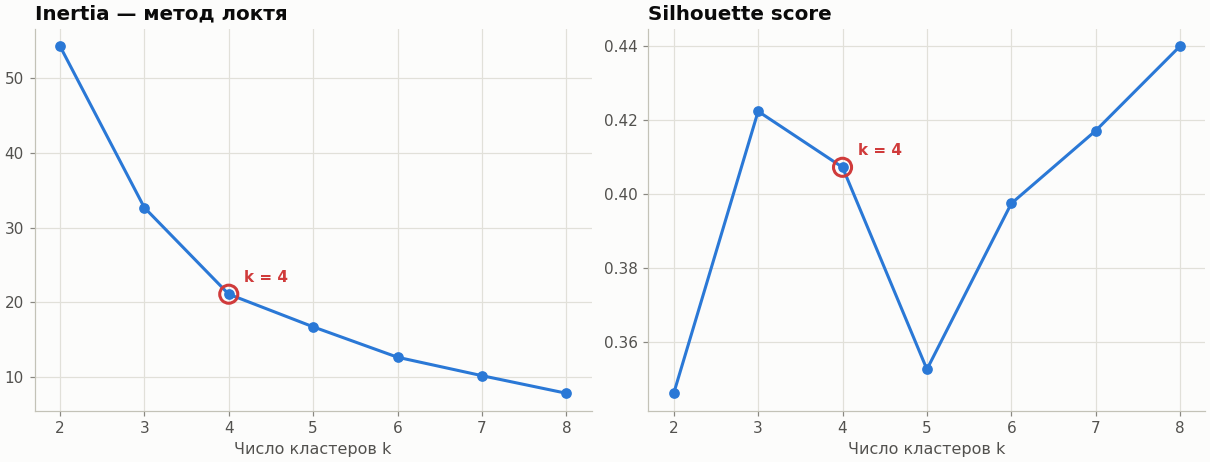

In [7]:
def evaluate_k(X: npt.NDArray[np.float64], k_values: range) -> pd.DataFrame:
    """Inertia и silhouette для каждого k (n_init=50 — устойчивость к инициализации)."""
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE).fit(X)
        rows.append({"k": k, "inertia": model.inertia_, "silhouette": silhouette_score(X, model.labels_)})
    return pd.DataFrame(rows)


def plot_k_selection(scores: pd.DataFrame, chosen_k: int) -> Figure:
    """Две панели (разные шкалы — разные графики, без второй оси Y)."""
    fig, (ax_elbow, ax_sil) = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
    panels = [(ax_elbow, "inertia", "Inertia — метод локтя"), (ax_sil, "silhouette", "Silhouette score")]
    for ax, column, title in panels:
        ax.plot(scores["k"], scores[column], color=WIN_COLOR, linewidth=2, marker="o", markersize=6)
        chosen = scores.loc[scores["k"] == chosen_k, column].iloc[0]
        ax.scatter([chosen_k], [chosen], s=140, facecolors="none", edgecolors=LOSS_COLOR, linewidths=2, zorder=3)
        ax.annotate(f"k = {chosen_k}", xy=(chosen_k, chosen), xytext=(10, 8),
                    textcoords="offset points", color=LOSS_COLOR, fontweight="semibold")
        ax.set(xlabel="Число кластеров k", xticks=list(scores["k"]))
        ax.set_title(title)
    return fig


k_scores = evaluate_k(X_scaled, K_RANGE)
display(k_scores)
save_figure(plot_k_selection(k_scores, N_CLUSTERS), "kmeans_k_selection.png")
plt.show()

**Как читать.** Локоть на inertia приходится на k = 3–4, а silhouette почти
одинаков для k = 3 (0.42) и k = 4 (0.41). Данные сами по себе не дают однозначного
ответа: 30 игроков и три признака — небольшая выборка. Берём **k = 4**, потому что
это обосновано предметной областью (4 классических типажа) и не ухудшает качество
по метрикам. При k = 3 TAG и LAG склеиваются в одну «регулярную» группу.

### 3.3. Обучение итоговой модели (k = 4)

In [8]:
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=50, random_state=RANDOM_STATE)
players["cluster"] = kmeans.fit_predict(X_scaled)

# Центры кластеров — обратно в исходные единицы (проценты), чтобы их можно было читать
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=FEATURES)
centroids["players"] = players["cluster"].value_counts().sort_index()
centroids["avg_bb_per_100"] = players.groupby("cluster")["bb_per_100"].mean()
display(centroids.round(1))

,vpip_pct,pfr_pct,three_bet_pct,players,avg_bb_per_100
0,26.7,21.3,10.0,7,28.8
1,10.4,7.6,1.4,6,23.3
2,33.4,10.7,0.6,5,-55.8
3,18.4,14.3,5.3,12,-6.1


## 4. Насколько K-Means восстановил профили?

Номера кластеров произвольны (кластер 0 — не обязательно Nit). Чтобы сравнить их
со стилями, нужно найти **лучшее взаимно-однозначное соответствие** «кластер → стиль».
Это задача о назначениях; решаем её венгерским алгоритмом
(`scipy.optimize.linear_sum_assignment`) по таблице сопряжённости.

Метрики, не зависящие от нумерации кластеров:
* **ARI** (Adjusted Rand Index): 1 — полное совпадение разбиений, ≈0 — случайное;
* **NMI** (Normalized Mutual Information): доля общей информации в разбиениях, 0…1.

In [9]:
def match_clusters_to_labels(clusters: pd.Series, labels: pd.Series) -> dict[int, str]:
    """Оптимальное соответствие кластер → метка (максимум совпадений)."""
    contingency = pd.crosstab(clusters, labels).reindex(columns=list(STYLE_ORDER), fill_value=0)
    row_idx, col_idx = linear_sum_assignment(-contingency.to_numpy())   # минус — ищем максимум
    return {int(contingency.index[r]): str(contingency.columns[c]) for r, c in zip(row_idx, col_idx)}


def agreement_scores(predicted: pd.Series, reference: pd.Series) -> dict[str, float]:
    """Accuracy после сопоставления + ARI и NMI."""
    return {
        "accuracy": float((predicted == reference).mean()),
        "ARI": adjusted_rand_score(reference, predicted),
        "NMI": normalized_mutual_info_score(reference, predicted),
    }


# Имена кластерам даём по согласию с SQL-правилом — это интерпретация, не обучение
cluster_names = match_clusters_to_labels(players["cluster"], players["player_style"])
players["ml_style"] = players["cluster"].map(cluster_names)
centroids.index = centroids.index.map(cluster_names)
print("Соответствие кластеров стилям:", cluster_names)

print("\nK-Means (строки) × SQL-правило (столбцы):")
display(pd.crosstab(players["ml_style"], players["player_style"])
        .reindex(index=list(STYLE_ORDER), columns=list(STYLE_ORDER), fill_value=0))

comparison = pd.DataFrame({
    "K-Means vs SQL-правило": agreement_scores(players["ml_style"], players["player_style"]),
    "K-Means vs ground truth": agreement_scores(players["ml_style"], players["true_style"]),
    "SQL-правило vs ground truth": agreement_scores(players["player_style"], players["true_style"]),
}).T
display(comparison.round(3))

Соответствие кластеров стилям: {0: 'LAG', 1: 'Nit', 2: 'Loose-Passive', 3: 'TAG'}

K-Means (строки) × SQL-правило (столбцы):


player_style,Nit,TAG,LAG,Loose-Passive
ml_style,,,,
Nit,6,0,0,0
TAG,2,9,0,1
LAG,0,3,4,0
Loose-Passive,0,0,0,5


,accuracy,ARI,NMI
K-Means vs SQL-правило,0.80,0.49,0.65
K-Means vs ground truth,0.87,0.62,0.69
SQL-правило vs ground truth,0.87,0.66,0.78


### 4.1. На ком ошибается кластеризация?
Смотрим игроков, чей ML-кластер не совпал с настоящим архетипом.

In [10]:
mistakes = players.loc[players["ml_style"] != players["true_style"],
                       ["player_name", *FEATURES, "true_style", "player_style", "ml_style"]]
print(f"Ошибок K-Means относительно ground truth: {len(mistakes)} из {len(players)}")
display(mistakes.sort_values("vpip_pct"))

Ошибок K-Means относительно ground truth: 4 из 30


,player_name,vpip_pct,pfr_pct,three_bet_pct,true_style,player_style,ml_style
28,TiltedShark,13.3,9.9,6.1,Nit,Nit,TAG
3,ColdAce,21.5,17.3,9.5,TAG,TAG,LAG
27,TiltedFish,23.1,19.0,2.9,LAG,TAG,TAG
7,DarkFish,29.1,12.8,6.0,Loose-Passive,Loose-Passive,TAG


## 5. PCA: проекция на плоскость

Три признака → две главные компоненты. На графике:
* **цвет** — кластер K-Means, **форма маркера** — стиль по SQL-правилу
  (совпадение цвета и формы = согласие двух методов);
* **×** — центры кластеров; **стрелки** — вклад исходных признаков в компоненты (biplot).

Объяснённая дисперсия: PC1 = 63.5%, PC2 = 30.3%, вместе = 93.8%


,PC1,PC2
vpip_pct,0.45,0.81
pfr_pct,0.69,-0.03
three_bet_pct,0.57,-0.59


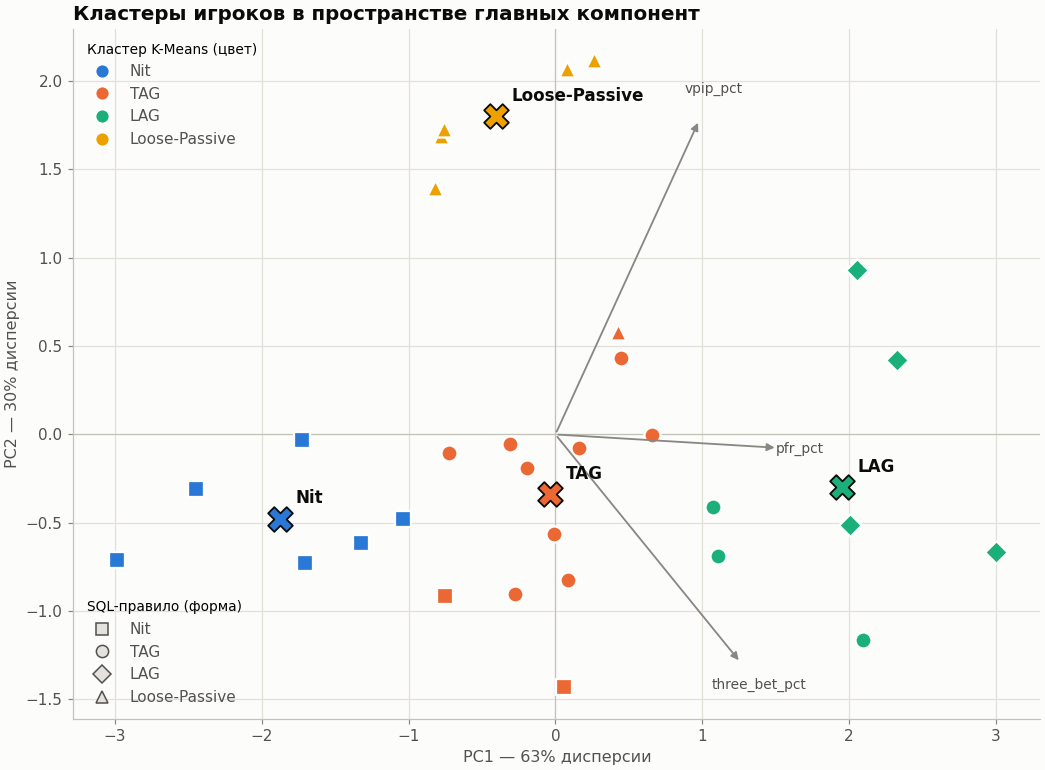

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
players[["pc1", "pc2"]] = coords
centroids_2d = pca.transform(kmeans.cluster_centers_)

explained = pca.explained_variance_ratio_
print(f"Объяснённая дисперсия: PC1 = {explained[0]:.1%}, PC2 = {explained[1]:.1%}, "
      f"вместе = {explained.sum():.1%}")
display(pd.DataFrame(pca.components_.T, index=FEATURES, columns=["PC1", "PC2"]).round(3))


def plot_pca_clusters(frame: pd.DataFrame, centers_2d: npt.NDArray[np.float64],
                      loadings: npt.NDArray[np.float64], variance: npt.NDArray[np.float64]) -> Figure:
    """Scatter игроков в пространстве PC1 × PC2 с центрами кластеров и нагрузками."""
    fig, ax = plt.subplots(figsize=(9.5, 7), layout="constrained")

    for style in STYLE_ORDER:                         # цвет = ML-кластер, форма = SQL-стиль
        for sql_style, group in frame[frame["ml_style"] == style].groupby("player_style"):
            ax.scatter(group["pc1"], group["pc2"], s=110, color=STYLE_COLORS[style],
                       marker=STYLE_MARKERS[sql_style], edgecolors="white", linewidths=1.5, zorder=3)

    for (cx, cy), name in zip(centers_2d, [cluster_names[i] for i in range(len(centers_2d))]):
        ax.scatter(cx, cy, marker="X", s=260, color=STYLE_COLORS[name],
                   edgecolors=INK_PRIMARY, linewidths=1.2, zorder=4)
        ax.annotate(name, xy=(cx, cy), xytext=(10, 10), textcoords="offset points",
                    fontsize=11, fontweight="semibold", color=INK_PRIMARY, zorder=5)

    _draw_loadings(ax, loadings, scale=2.2)

    color_handles = [Line2D([], [], marker="o", linestyle="none", markersize=9,
                            markerfacecolor=STYLE_COLORS[s], markeredgecolor="white", label=s)
                     for s in STYLE_ORDER]
    shape_handles = [Line2D([], [], marker=STYLE_MARKERS[s], linestyle="none", markersize=8,
                            markerfacecolor=NEUTRAL_MID, markeredgecolor=INK_SECONDARY, label=s)
                     for s in STYLE_ORDER]
    legend_ml = ax.legend(handles=color_handles, title="Кластер K-Means (цвет)",
                          loc="upper left", title_fontsize=9, alignment="left")
    ax.add_artist(legend_ml)
    ax.legend(handles=shape_handles, title="SQL-правило (форма)",
              loc="lower left", title_fontsize=9, alignment="left")

    ax.axhline(0, color=BASELINE_COLOR, linewidth=0.8, zorder=1)
    ax.axvline(0, color=BASELINE_COLOR, linewidth=0.8, zorder=1)
    ax.set(xlabel=f"PC1 — {variance[0]:.0%} дисперсии", ylabel=f"PC2 — {variance[1]:.0%} дисперсии")
    ax.set_title("Кластеры игроков в пространстве главных компонент")
    return fig


def _draw_loadings(ax: Axes, loadings: npt.NDArray[np.float64], scale: float) -> None:
    """Стрелки нагрузок признаков (biplot): куда «тянет» каждый исходный признак."""
    for feature, (dx, dy) in zip(FEATURES, loadings.T * scale):
        ax.annotate("", xy=(dx, dy), xytext=(0, 0),
                    arrowprops={"arrowstyle": "-|>", "color": INK_MUTED, "linewidth": 1.2})
        ax.text(dx * 1.1, dy * 1.1, feature, color=INK_SECONDARY, fontsize=9, ha="center", va="center")


fig_pca = plot_pca_clusters(players, centroids_2d, pca.components_, explained)
save_figure(fig_pca, "pca_clusters.png")
plt.show()

## 6. Динамика банкролла

Считаем кумулятивный профит **прямо в SQL** оконной функцией
`SUM(...) OVER (PARTITION BY player ORDER BY time)`. Игроков выбираем в CTE:
топ-3 по итоговому профиту и топ-3 по убытку (`ROW_NUMBER()` в обе стороны).
Профит переводим в большие блайнды, чтобы результат не зависел от ставок стола.

In [12]:
BANKROLL_SQL: Final[str] = """
WITH totals AS (
    SELECT player_id, SUM(net_result) AS total_net
    FROM hand_players
    GROUP BY player_id
),
ranked AS (
    SELECT player_id,
           ROW_NUMBER() OVER (ORDER BY total_net DESC) AS rank_best,
           ROW_NUMBER() OVER (ORDER BY total_net ASC)  AS rank_worst
    FROM totals
),
selected AS (
    SELECT player_id,
           CASE WHEN rank_best <= :top_n THEN 'winner' ELSE 'loser' END AS player_group
    FROM ranked
    WHERE rank_best <= :top_n OR rank_worst <= :top_n
)
SELECT
    p.player_name,
    s.player_group,
    h.hand_id,
    h.played_at,
    ROW_NUMBER() OVER player_timeline                                  AS hand_no,
    SUM(CAST(hp.net_result AS REAL) / h.big_blind) OVER (
        player_timeline ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    )                                                                  AS cumulative_bb
FROM selected     AS s
JOIN hand_players AS hp ON hp.player_id = s.player_id
JOIN hands        AS h  ON h.hand_id    = hp.hand_id
JOIN players      AS p  ON p.player_id  = s.player_id
WINDOW player_timeline AS (PARTITION BY hp.player_id ORDER BY h.played_at, h.hand_id)
ORDER BY p.player_name, hand_no
"""

bankroll = query(BANKROLL_SQL, params={"top_n": TOP_N_BANKROLL})
bankroll["played_at"] = pd.to_datetime(bankroll["played_at"])

final_results = (bankroll.groupby(["player_name", "player_group"], as_index=False)
                 .agg(hands=("hand_no", "max"), final_bb=("cumulative_bb", "last"),
                      peak_bb=("cumulative_bb", "max"), trough_bb=("cumulative_bb", "min"))
                 .sort_values("final_bb", ascending=False, ignore_index=True))
final_results = final_results.merge(players[["player_name", "player_style", "true_style"]], on="player_name")
display(final_results)

,player_name,player_group,hands,final_bb,peak_bb,trough_bb,player_style,true_style
0,SneakyRiver,winner,203,234.00,236.5,-5.50,Nit,Nit
1,TiltedBluff,winner,193,199.00,211.0,-19.00,LAG,LAG
2,BigRiver,winner,197,184.50,189.5,-7.50,LAG,LAG
3,ColdDonk,loser,205,-173.15,7.0,-175.65,Loose-Passive,Loose-Passive
4,RoyalBluff,loser,215,-177.00,37.0,-216.50,Loose-Passive,Loose-Passive
5,BigShark,loser,203,-305.00,21.5,-307.50,Loose-Passive,Loose-Passive


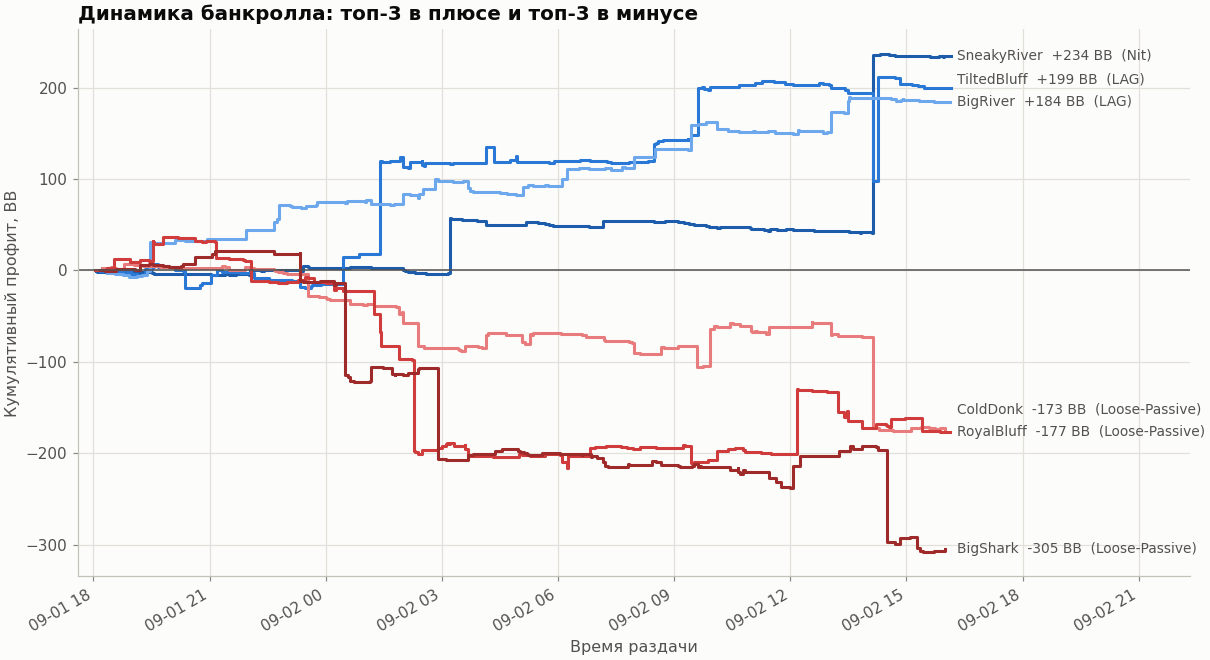

In [13]:
# Оттенки внутри группы: победители — синие, проигравшие — красные.
# Идентичность игрока дублируется подписью в конце линии (не только цветом).
GROUP_SHADES: Final[dict[str, list[str]]] = {
    "winner": ["#1c5cab", "#2a78d6", "#6da7ec"],
    "loser": ["#e87b7b", "#d03b3b", "#9e2a2a"],   # порядок: от меньшего убытка к большему
}


def spread_labels(values: npt.NDArray[np.float64], min_gap: float) -> npt.NDArray[np.float64]:
    """Раздвигает Y-координаты подписей снизу вверх, чтобы между ними было не меньше min_gap."""
    placed = values.astype(float).copy()
    order = np.argsort(values)
    for previous, current in zip(order[:-1], order[1:]):
        placed[current] = max(placed[current], placed[previous] + min_gap)
    return placed


def plot_bankroll(frame: pd.DataFrame, results: pd.DataFrame) -> Figure:
    """Кумулятивный профит в BB во времени для лучших и худших игроков."""
    fig, ax = plt.subplots(figsize=(11, 6), layout="constrained")
    shade_iter = {group: iter(shades) for group, shades in GROUP_SHADES.items()}

    y_span = frame["cumulative_bb"].max() - frame["cumulative_bb"].min()
    label_y = spread_labels(results["final_bb"].to_numpy(), min_gap=0.045 * y_span)
    label_x = frame["played_at"].max() + pd.Timedelta(minutes=10)

    for row, y_text in zip(results.itertuples(index=False), label_y):
        series = frame[frame["player_name"] == row.player_name]
        color = next(shade_iter[row.player_group])
        ax.plot(series["played_at"], series["cumulative_bb"], color=color, linewidth=2,
                drawstyle="steps-post")
        ax.text(label_x, y_text, f"{row.player_name}  {row.final_bb:+.0f} BB  ({row.player_style})",
                va="center", fontsize=9, color=INK_SECONDARY)

    ax.axhline(0, color=INK_SECONDARY, linewidth=1)
    ax.set(ylabel="Кумулятивный профит, BB", xlabel="Время раздачи")
    ax.margins(x=0.02)
    ax.set_xlim(right=frame["played_at"].max() + (frame["played_at"].max() - frame["played_at"].min()) * 0.28)
    fig.autofmt_xdate()
    ax.set_title(f"Динамика банкролла: топ-{TOP_N_BANKROLL} в плюсе и топ-{TOP_N_BANKROLL} в минусе")
    return fig


fig_bankroll = plot_bankroll(bankroll, final_results)
save_figure(fig_bankroll, "bankroll_dynamics.png")
plt.show()

## 7. Выводы

**EDA**
* 61% раздач заканчиваются префлоп (медиана банка 4 BB). Раздачи, дошедшие до флопа,
  дают медианный банк 12 BB и хвост до 300 BB. Банк распределён логнормально, поэтому
  в моделях его стоит логарифмировать.
* PFR и 3-bet % сильно связаны (r = 0.69), AF и WTSD — обратно (r = −0.49):
  агрессивные игроки забирают банки ставками и реже доходят до вскрытия.
  VPIP слабо отрицательно связан с винрейтом (r = −0.26) — лузовая игра наказывается.

**K-Means (k = 4, StandardScaler)**
* Центры кластеров легко читаются как типажи: Nit (VPIP ≈ 10%), TAG (≈ 18%),
  LAG (≈ 27%, 3-bet ≈ 10%), Loose-Passive (≈ 33%, PFR всего ≈ 11%).
* Без учителя модель восстановила настоящий архетип у **26 из 30 игроков (87%,
  ARI = 0.62, NMI = 0.69)** — столько же, сколько SQL-правило, написанное вручную
  (87%, ARI = 0.66). Правило чуть точнее в «форме» разбиения, но требует экспертных порогов;
  K-Means нашёл те же группы сам.
* Все 4 ошибки — на границах соседних типажей и связаны с шумным 3-bet %
  (60–100 возможностей на игрока): например, Fish с редким для себя 3-bet 6% попал в TAG.

**PCA**
* Две компоненты сохраняют 94% дисперсии. PC1 (63%) — «общая агрессия»: все признаки
  входят с плюсом, сильнее всего PFR. PC2 (30%) противопоставляет VPIP и 3-bet —
  это ось «лузово-пассивности», по которой Fish уходят далеко от остальных.

**Банкролл**
* Все три худших игрока — Loose-Passive (от −173 до −305 BB), лучшие — Nit и два LAG.
* Кривые растут ступенями: итог часто решают 1–2 крупных банка (у SneakyRiver
  +195 BB за одну раздачу). 200 раздач на игрока — это ещё не навык, а во многом дисперсия.

**Ограничения и следующие шаги**
* 30 игроков — маленькая выборка для кластеризации; при `--hands 50000 --players 80`
  частоты станут стабильнее, и границы TAG/LAG должны разделиться чище.
* Добавить постфлоп-признаки (AF, WTSD) и сравнить K-Means с GaussianMixture,
  который даёт вероятности принадлежности, а не жёсткие метки.